<a href="https://colab.research.google.com/github/Alheri123/Alheri_medical_insurance_predication./blob/main/Copy_of_Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Medical Insurance Cost Analysis & Prediction
# SheCode Africa – Data Analysis & Machine Learning Capstone Project

Student: Alheri Joshua
Model: Linear Regression
Environment: Python (Google Colab)


# Project Background
This project analyzes the "Medical Cost Personal Dataset" from Kaggle, which contains information on 1,338 insured individuals.
Variables include: age, sex, BMI, number of children, smoking status, region, and medical charges.
The target variable is 'charges' (medical insurance cost billed to the individual).


# Project Objectives
1. Understand demographic and lifestyle characteristics associated with medical insurance costs.
2. Perform data cleaning and exploratory analysis in Python.
3. Investigate relationships between age, BMI, smoking status, family size, and charges.
4. Identify factors associated with higher medical costs.
5. Build and evaluate a **Linear Regression model** to predict insurance charges.
6. Interpret model coefficients and provide actionable insights.
7. Suggest recommendations for insurance analytics and planning.



# Tools & Libraries
- pandas – data handling
- numpy – numerical operations
- matplotlib & seaborn – visualizations
- scikit-learn – machine learning (Linear Regression, evaluation metrics)



# Dataset
- Source: Kaggle – 'Medical Cost Personal Dataset'
- File: `insurance.csv`
- Target Variable: `charges`
- Predictor Variables: `age`, `sex`, `bmi`, `children`, `smoker`, `region`



# Workflow
1. Load and inspect dataset
2. Exploratory Data Analysis (EDA) with visualizations
3. Encode categorical variables
4. Train/test split
5. Build Linear Regression model
6. Evaluate performance (MAE, MSE, RMSE, R²)
7. Interpret coefficients
8. Document insights and recommend byations

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


# Data Cleaning

In this step, we check the dataset to ensure it is ready for analysis.  
We will look at:
- Shape (rows and columns)  
- Column names and data types  
- Missing values  
- Duplicate rows  
- Outliers in numeric columns

In [ ]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df. head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
df. dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

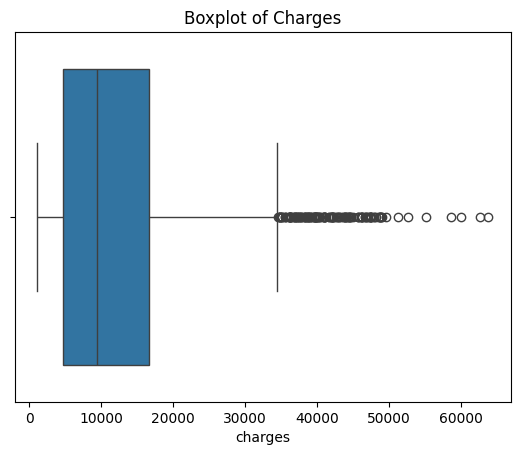

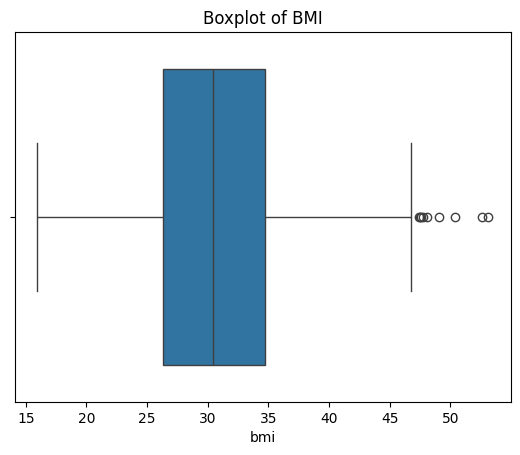

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['charges'])
plt.title("Boxplot of Charges")
plt.show()

sns.boxplot(x=df['bmi'])
plt.title("Boxplot of BMI")
plt.show()

In [ ]:
# Exploratory Data Analysis (EDA)

In this step, we explore the dataset with visualizations to understand patterns.
We will look at:
- Distribution of charges
- Charges by smoker status
- Age vs charges
- BMI vs charges
- Children vs charges
- Region vs charges
- Smoker + BMI interaction
- Correlation heatmap

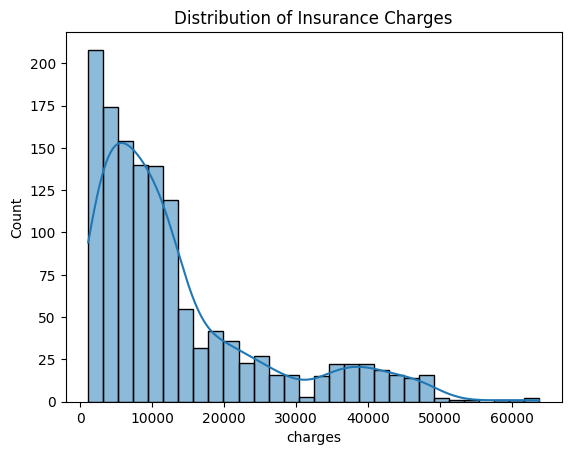

In [ ]:


1 #Distributions of Charges.

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

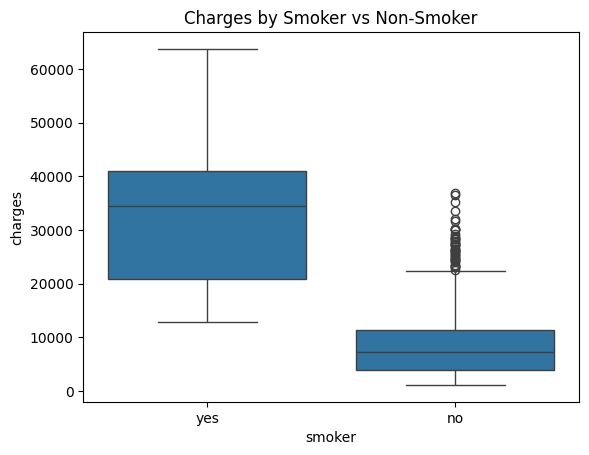

In [ ]:
2 #Charges by smoker status.

sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker vs Non-Smoker")
plt.show()

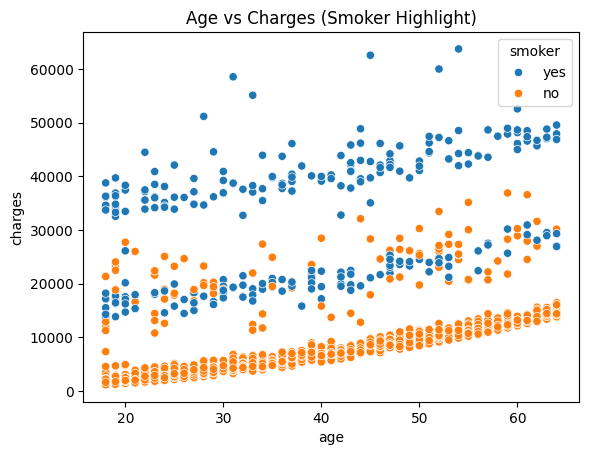

In [ ]:
3, #Age vs Charges.

sns.scatterplot(x='age', y='charges', data=df, hue='smoker')
plt.title("Age vs Charges (Smoker Highlight)")
plt.show()

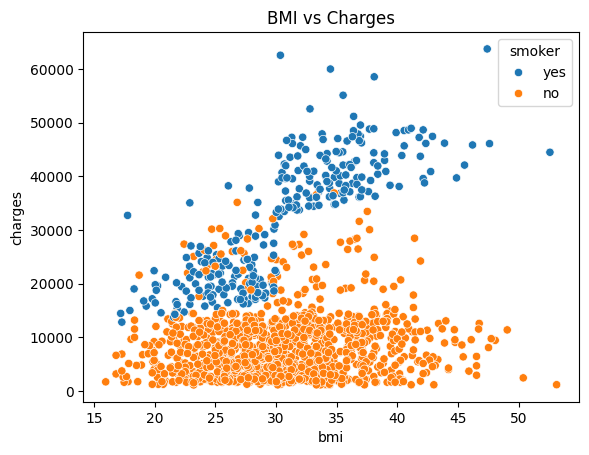

In [ ]:
4,# BMI vs Charges.

sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')
plt.title("BMI vs Charges")
plt.show()

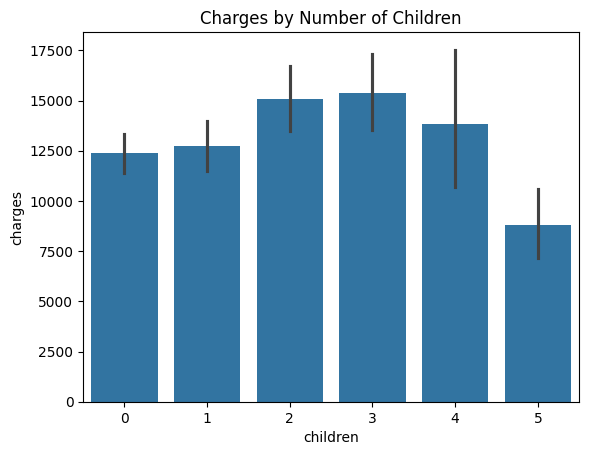

In [ ]:
5,# Children vs Charges.

sns.barplot(x='children', y='charges', data=df)
plt.title("Charges by Number of Children")
plt.show()

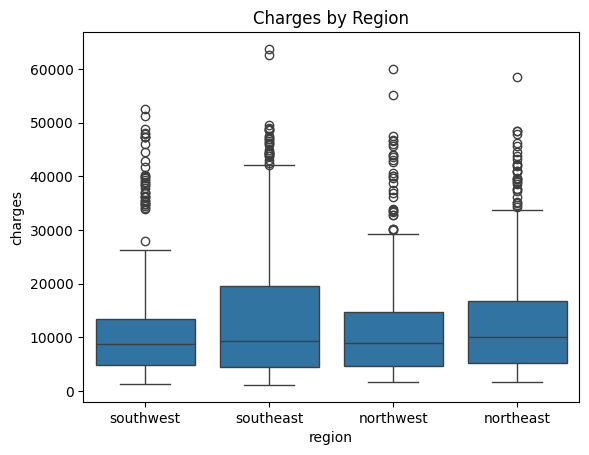

In [ ]:
6,# Region vs Charges.

sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")
plt.show()

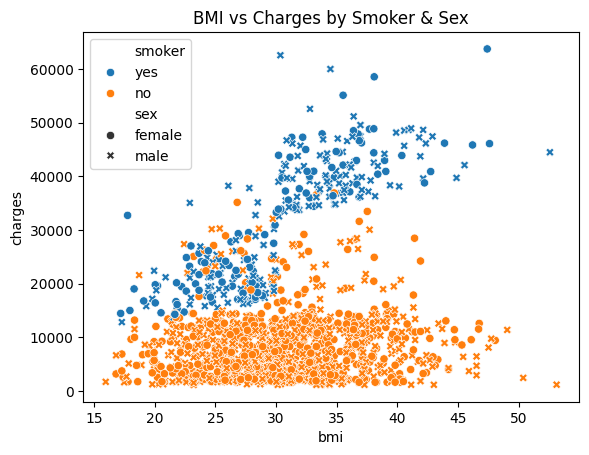

In [ ]:
7,# Smokers vs BMI interaction.

sns.scatterplot(x='bmi', y='charges', hue='smoker', style='sex', data=df)
plt.title("BMI vs Charges by Smoker & Sex")
plt.show()

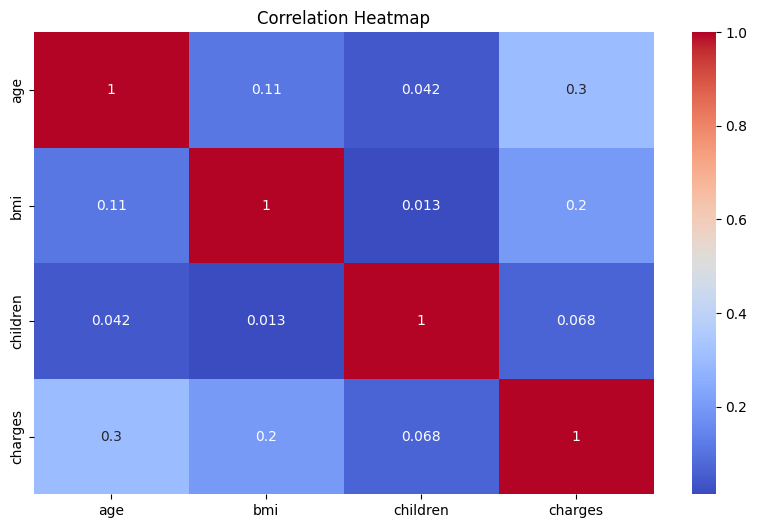

In [ ]:
8,# Correlation Heatmap.

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Encoding Categorical Variables

Our dataset contains categorical features (`sex`, `smoker`, `region`) that cannot be used directly in regression models.  
We convert them into numeric form using one‑hot encoding so the model can process them.  
This step ensures all variables are numeric and ready for train/test splitting.

In [ ]:
# Encode categorical variables explicitly
df_encoded = pd.get_dummies(df, columns=['sex','smoker','region'], drop_first=True)

# Preview the new dataset
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# Train/Test Split

To evaluate our regression model properly, we split the dataset into training and testing sets.  
The training set is used to fit the model, while the testing set is used to measure performance on unseen data.  
We will use an 80/20 split with a fixed random state for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1070, 8), (268, 8), (1070,), (268,))

# Linear Regression Modeling

We now build a Linear Regression model using the training set.  
The model will learn the relationship between independent variables and the target variable (`charges`).  
After training, we will make predictions on the test set to evaluate performance.

In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model on training data
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Preview first 10 predictions vs actual values
pd.DataFrame({'Actual': y_test[:10].values, 'Predicted': y_pred[:10]})

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457
5,4536.25900,10864.113164
6,2117.33885,170.280841
7,14210.53595,16903.450287
8,3732.62510,1092.430936
9,10264.44210,11218.343184


# Model Evaluation

We evaluate the Linear Regression model using three metrics:
- **Mean Absolute Error (MAE):** Average absolute difference between predicted and actual values.  
- **Mean Squared Error (MSE):** Average squared difference (penalizes larger errors).  
- **R² Score:** Proportion of variance explained by the model (closer to 1 is better).

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 4181.19447375365
Mean Squared Error (MSE): 33596915.85136145
R² Score: 0.7835929767120724


# Interpretation of Coefficients

Linear Regression produces coefficients for each independent variable.  
These coefficients represent how much the target (`charges`) changes when the variable increases by one unit, holding all other variables constant.  

- Positive coefficient → increases charges.  
- Negative coefficient → decreases charges.  
- Larger magnitude → stronger influence.

In [ ]:
# Get model coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Add intercept
intercept = model.intercept_

print("Intercept:", intercept)
coefficients

Intercept: -11931.21905032666


,Feature,Coefficient
0,age,256.975706
1,bmi,337.092552
2,children,425.278784
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


# Visualization of Predictions

To better understand model performance, we plot the predicted charges against the actual charges.  
A perfect model would have all points lying on the diagonal line (y = x).  
This visualization helps us see whether the model systematically underestimates or overestimates charges.

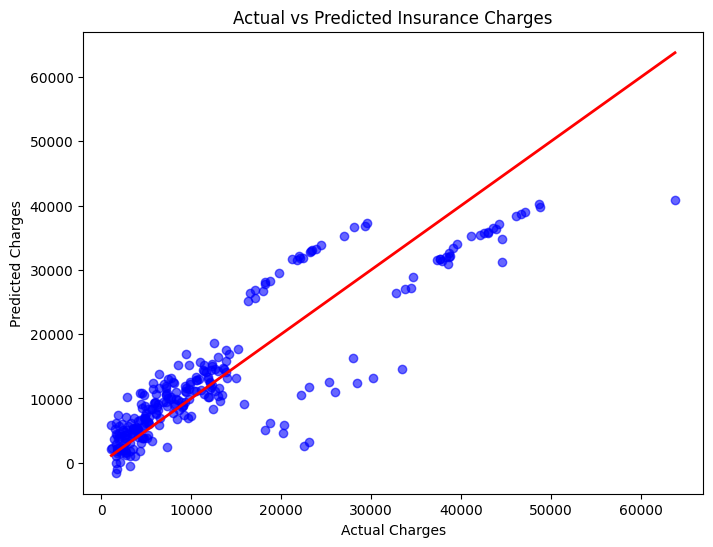

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of actual vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# Plot the ideal line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

# Residual Analysis

Residuals are the differences between actual and predicted values.  
By analyzing residuals, we check whether the assumptions of Linear Regression hold true.  
A good model should have residuals randomly scattered around zero without clear patterns.

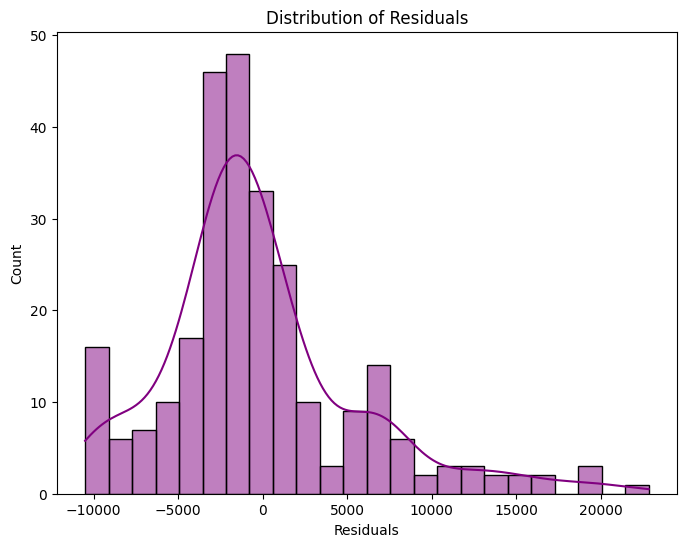

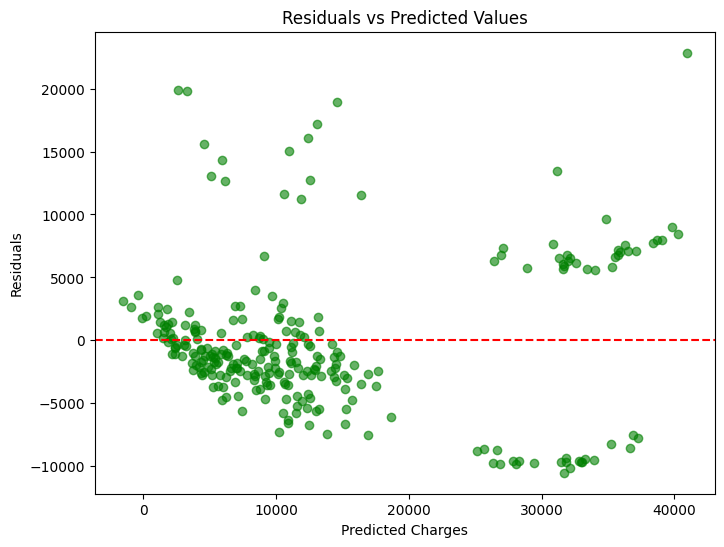

In [ ]:
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals distribution
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

# Scatter plot of residuals vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='green', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.show()

# Model Improvement

While Linear Regression provides a baseline, we can improve performance by:
- Adding polynomial features to capture non-linear relationships.
- Using regularization methods (Ridge, Lasso) to reduce overfitting.
- Feature engineering (e.g., interaction terms between BMI and smoker).
- Trying alternative models like Decision Trees or Random Forests for comparison.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression (L2 regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Lasso Regression (L1 regularization)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# Evaluate Ridge and Lasso
print("Ridge R²:", r2_score(y_test, ridge_pred))
print("Lasso R²:", r2_score(y_test, lasso_pred))

Ridge R²: 0.7832830144988215
Lasso R²: 0.7835924268063132


# Project Conclusion

In this project, we built a Linear Regression model to predict insurance charges.  
We followed the complete workflow:
- Data Cleaning and Exploratory Data Analysis (EDA)  
- Encoding categorical variables  
- Train/Test Split  
- Model training with Linear Regression  
- Evaluation using MAE, MSE, and R²  
- Interpretation of coefficients  
- Visualization of predictions  
- Residual analysis and model improvement  

### Key Insights:
- Smoking status had the strongest positive impact on charges.  
- BMI and age also contributed significantly to higher costs.  
- Number of children and region had relatively

 Future Work

- Collect more data to improve generalization.  
- Explore advanced models (Random Forest, Gradient Boosting, Neural Networks).  
- Add interaction terms (e.g., smoker × BMI) to capture complex relationships.  
- Perform hyperparameter tuning for Ridge/Lasso.  
- Deploy the model as an API for real-world use.